In [1]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pyBigWig

In [15]:
# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
cell_calling_comparison_dir = os.path.join(entropy_dir, '_cell_calling_comparison')

Union_3set_atac_BCs_file = os.path.join(cell_calling_comparison_dir, '_Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
Union_3set_atac_BCs_df = pd.read_csv(Union_3set_atac_BCs_file, sep='\t')


In [2]:
hg38_genes_file='/home/syyang/CR/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/genes/genes.gtf.gz'
hg38_genes_df = pd.read_csv(hg38_genes_file, sep='\t', comment='#', header=None,
                            names=['chrom', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'],
                            compression='gzip')
hg38_genes_genes_df = hg38_genes_df[hg38_genes_df['feature'] == 'gene'].copy()


hg38_genes_genes_df['gene_name'] = hg38_genes_genes_df['attribute'].apply(lambda x: [item for item in x.split(';') if 'gene_name' in item][0].split(' ')[-1].replace('"', ''))
hg38_genes_genes_df.head(2)

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_name
0,chr1,HAVANA,gene,29554,31109,.,+,.,"gene_id ""ENSG00000243485""; gene_version ""5""; g...",MIR1302-2HG
8,chr1,HAVANA,gene,34554,36081,.,-,.,"gene_id ""ENSG00000237613""; gene_version ""2""; g...",FAM138A


# Comparsion of DNA-debris vs Nuclei droplets 

In [3]:

# Load the data

entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/'
Union_cells_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')

cmp_DNAdebris = os.path.join(Union_cells_subdir, 'cmp_DNAdebris_entropy')
mosdepth_res_subdir = os.path.join(cmp_DNAdebris, '_mosdepth_res')


# dna_debri_per_base_file = os.path.join(mosdepth_res_subdir, 'DNAdebris_fragments.bam.per-base.bed.gz')
# nodna_debri_per_base_file = os.path.join(mosdepth_res_subdir, 'NotDNAdebris_fragments.bam.per-base.bed.gz')
dna_debri_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_DNAdebris_fragments.bam.per-base.bed.gz')
nodna_debri_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_NotDNAdebris_fragments.bam.per-base.bed.gz')


# Columns: Chromosome, Start, End, Depth
df_dnadebris= pd.read_csv(dna_debri_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')
df_nodnadebris= pd.read_csv(nodna_debri_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')

# Calculate the width of each interval (useful for finding outlier regions)
df_dnadebris['width'] = df_dnadebris['end'] - df_dnadebris['start']
df_nodnadebris['width'] = df_nodnadebris['end'] - df_nodnadebris['start']

# 22 droplets as DNA-debris
# 2362 droplets as no-DNA-debris
df_dnadebris['depth_norm_by_droplets'] = df_dnadebris['depth'] / 22
df_nodnadebris['depth_norm_by_droplets'] = df_nodnadebris['depth'] / 2362

In [4]:
df_dnadebris.head(2)

,chrom,start,end,depth,width,depth_norm_by_droplets
0,chr1,792500,792652,1,152,0.045455
1,chr1,792652,792877,0,225,0.000000


In [5]:
# calculate depth ratio 
_df1 =pd.DataFrame(columns=['type', 'depth', 'bp_coverage'],)

for df, type in zip([df_dnadebris, df_nodnadebris], ['dna_debris', 'no_dna_debris']):
    for depth in df['depth'].unique():
        total_bp = df[df['depth'] == depth]['width'].sum()
        # add row to dataframe
        _df1.loc[len(_df1)] = [type, depth, total_bp]


In [6]:
# 22 droplets as DNA-debris
# 2362 droplets as no-DNA-debris

_df1.loc[_df1['type'] == 'dna_debris', 'depth_norm_by_droplets'] = _df1[_df1['type'] == 'dna_debris']['depth'] / 22
_df1.loc[_df1['type'] == 'no_dna_debris', 'depth_norm_by_droplets'] = _df1[_df1['type'] == 'no_dna_debris']['depth'] / 2362

Text(0, 0.5, 'Depth normalized by number of droplets')

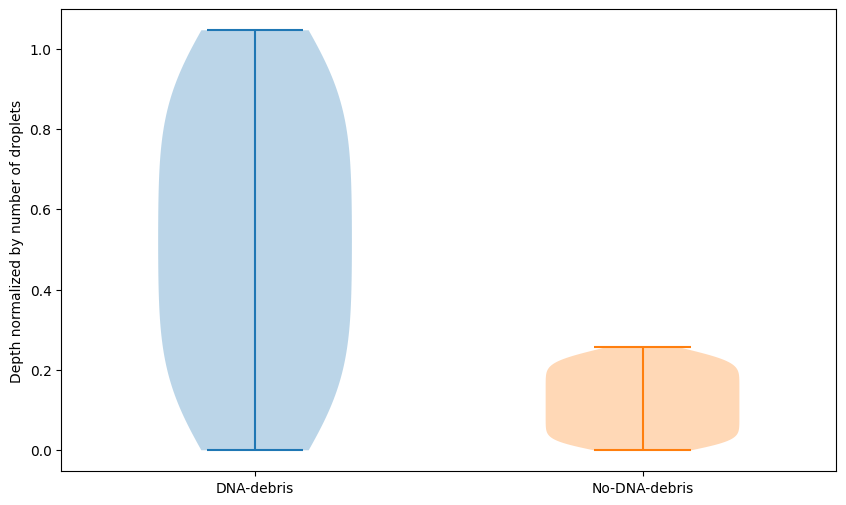

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.violinplot(_df1.loc[_df1['type'] == 'dna_debris']['depth_norm_by_droplets'], positions=[0])
ax.violinplot(_df1.loc[_df1['type'] == 'no_dna_debris']['depth_norm_by_droplets'], positions=[1])
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['DNA-debris', 'No-DNA-debris'])
ax.set_ylabel('Depth normalized by number of droplets')

Text(0.5, 1.0, 'chr1 Coverage Comparison')

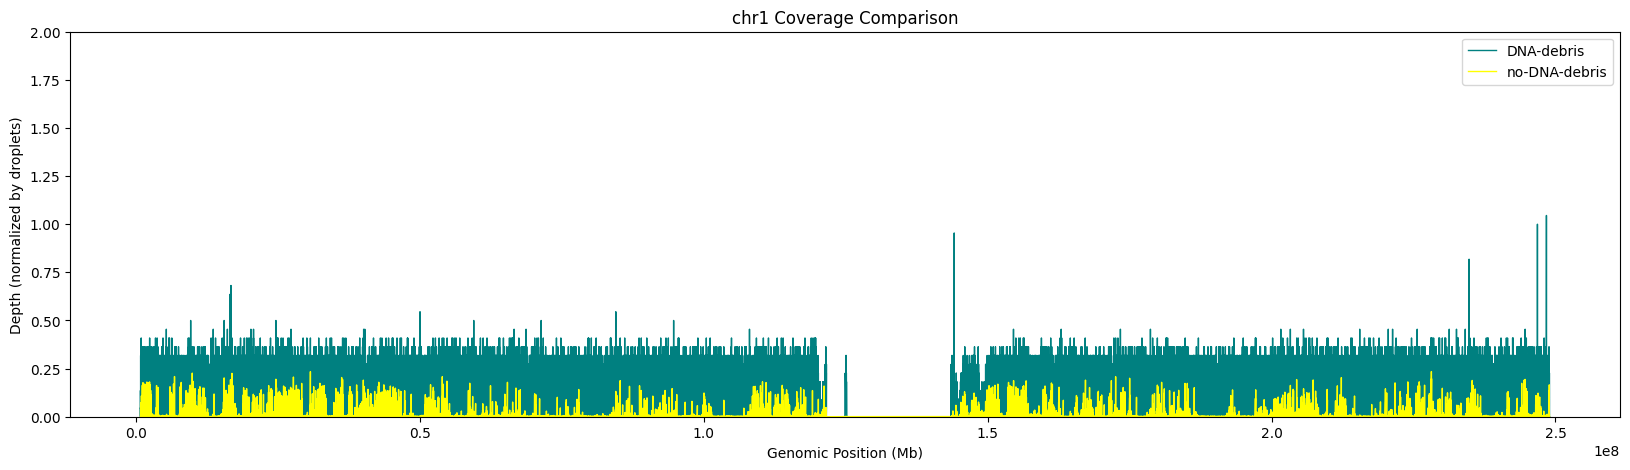

In [21]:
chrom = 'chr1'

fig, ax = plt.subplots(1, 1, figsize=(20, 5), sharey=True)
# Filter for a specific chromosome to make it manageable
chrom_df_dnadebris = df_dnadebris[df_dnadebris['chrom'] == chrom]
chrom_df_nodnadebris = df_nodnadebris[df_nodnadebris['chrom'] == chrom]


ax.step(chrom_df_dnadebris['start'], chrom_df_dnadebris['depth_norm_by_droplets'], where='post', color='teal', lw=1, label='DNA-debris')
ax.step(chrom_df_nodnadebris['start'], chrom_df_nodnadebris['depth_norm_by_droplets'], where='post', color='yellow', lw=1, label='no-DNA-debris')


ax.set_ylim(0, 2)
ax.set_xlabel('Genomic Position (Mb)')
ax.set_ylabel('Depth (normalized by droplets)')
ax.legend()

ax.set_title(f'{chrom} Coverage Comparison')

## Bigwig 

Coverage at chr6:32352749-32552077


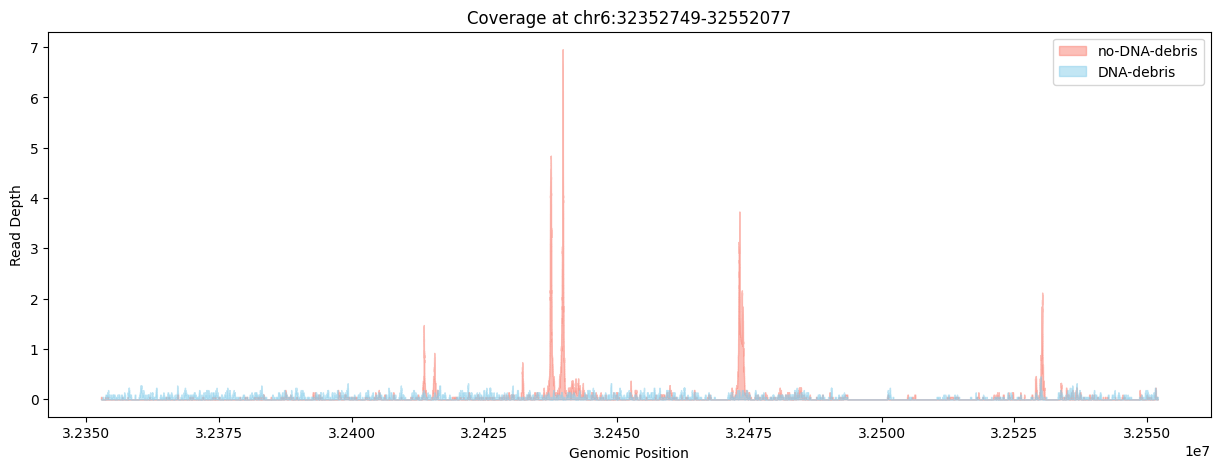

In [ ]:


cmp_dnadebris_subdir = os.path.join(Union_cells_subdir, 'cmp_DNAdebris_entropy')
dna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'DNAdebris_fragments.CPM.bw')

nodna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'NotDNAdebris_fragments.CPM.bw')
# Open the BigWig file
dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)

# Define your region of interest
chrom = "chr6"
start = 32352749
end = 32552077

# Extract values (returns a list of floats, one per base) & replace NaNs with 0
dna_debris_values = dna_debris_bw.values(chrom, start, end)
dna_debris_values = np.nan_to_num(dna_debris_values, nan=0.0)
no_dna_debris_values = no_dna_debris_bw.values(chrom, start, end)
no_dna_debris_values = np.nan_to_num(no_dna_debris_values, nan=0.0)


# Plotting
fix, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(range(start, end), no_dna_debris_values, color="salmon", alpha=0.5, label='no-DNA-debris')
ax.fill_between(range(start, end), dna_debris_values, color="skyblue", alpha=0.5, label='DNA-debris')
ax.set_title(f"Coverage at {chrom}:{start}-{end}")
ax.set_xlabel("Genomic Position")
ax.set_ylabel("Read Depth")
ax.legend()


print(f"Coverage at {chrom}:{start}-{end}")

no_dna_debris_bw.close()
dna_debris_bw.close()

Coverage at chr6:32352749-32552077


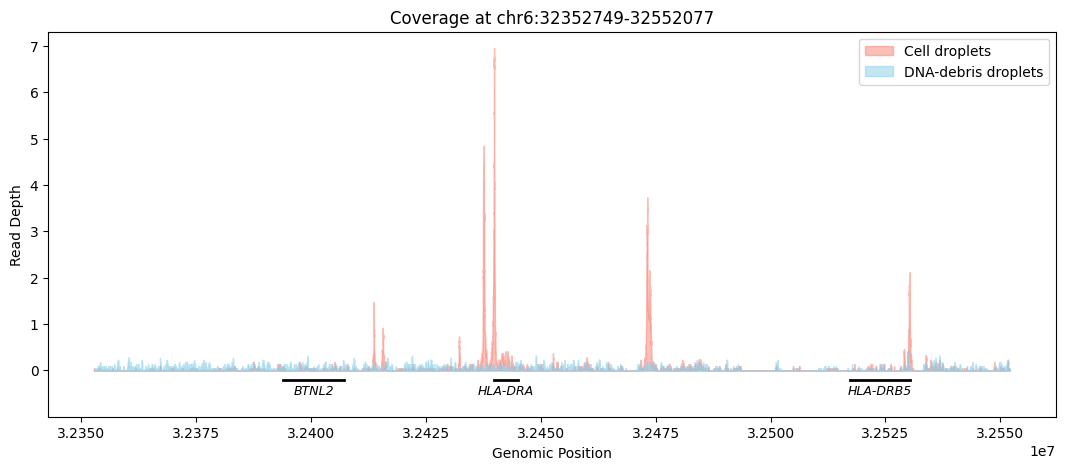

In [ ]:
chrom = "chr6"
start = 32352749
end = 32552077

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]




cmp_dnadebris_subdir = os.path.join(Union_cells_subdir, 'cmp_DNAdebris_entropy')
dna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'DNAdebris_fragments.CPM.bw')

nodna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'NotDNAdebris_fragments.CPM.bw')
# Open the BigWig file
dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)



# Extract values (returns a list of floats, one per base) & replace NaNs with 0
dna_debris_values = dna_debris_bw.values(chrom, start, end)
dna_debris_values = np.nan_to_num(dna_debris_values, nan=0.0)
no_dna_debris_values = no_dna_debris_bw.values(chrom, start, end)
no_dna_debris_values = np.nan_to_num(no_dna_debris_values, nan=0.0)



fig, (ax_cov) = plt.subplots(1, 1, figsize=(13, 5), )


ax_cov.fill_between(range(start, end), no_dna_debris_values, color="salmon", alpha=0.5, label='Cell droplets')
ax_cov.fill_between(range(start, end), dna_debris_values, color="skyblue", alpha=0.5, label='DNA-debris droplets')
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()


# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(dna_debris_values), max(no_dna_debris_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(dna_debris_values), max(no_dna_debris_values)) * 1.05, step=1))

print(f"Coverage at {chrom}:{start}-{end}")

no_dna_debris_bw.close()
dna_debris_bw.close()

Coverage at chr19:51370861-51393411


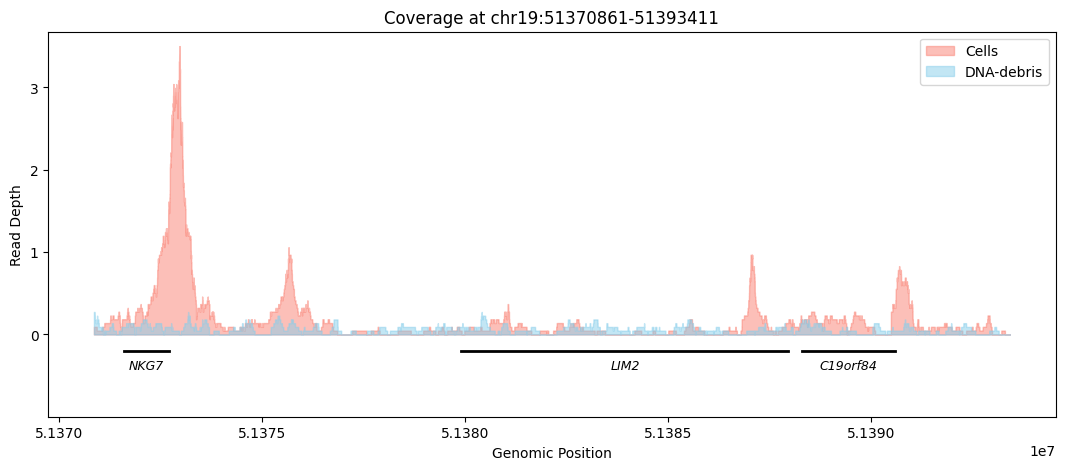

In [81]:
# region of interest
chrom = "chr19"
start = 51370861
end = 51393411

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]




cmp_dnadebris_subdir = os.path.join(Union_cells_subdir, 'cmp_DNAdebris_entropy')
dna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'DNAdebris_fragments.CPM.bw')

nodna_debris_bw_file = os.path.join(cmp_dnadebris_subdir, 'NotDNAdebris_fragments.CPM.bw')
# Open the BigWig file
dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)



# Extract values (returns a list of floats, one per base) & replace NaNs with 0
dna_debris_values = dna_debris_bw.values(chrom, start, end)
dna_debris_values = np.nan_to_num(dna_debris_values, nan=0.0)
no_dna_debris_values = no_dna_debris_bw.values(chrom, start, end)
no_dna_debris_values = np.nan_to_num(no_dna_debris_values, nan=0.0)



fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)


ax_cov.fill_between(range(start, end), no_dna_debris_values, color="salmon", alpha=0.5, label='Cells')
ax_cov.fill_between(range(start, end), dna_debris_values, color="skyblue", alpha=0.5, label='DNA-debris')
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(dna_debris_values), max(no_dna_debris_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(dna_debris_values), max(no_dna_debris_values)) * 1.05, step=1))



print(f"Coverage at {chrom}:{start}-{end}")

no_dna_debris_bw.close()
dna_debris_bw.close()

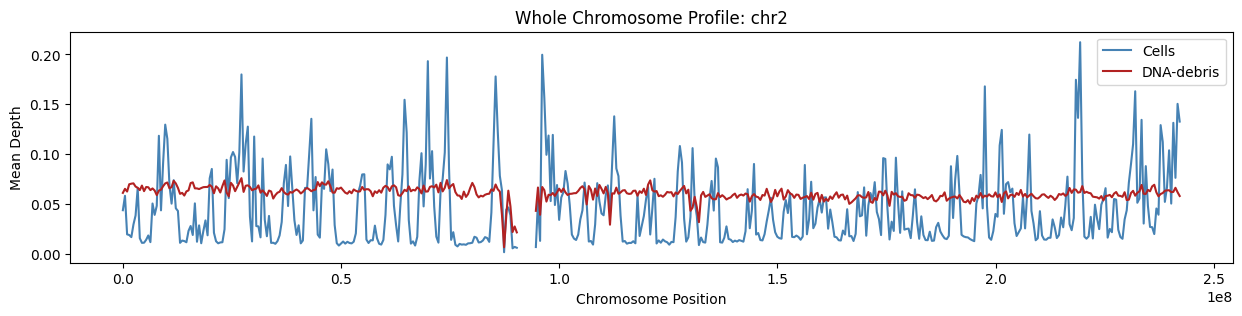

In [ ]:

This code snippet is performing the following tasks:
chrom = "chr2"

dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)

dna_debris_chrom_size = dna_debris_bw.chroms(chrom)
no_dna_debris_chrom_size = no_dna_debris_bw.chroms(chrom)

# Fetch the mean depth in 1000 equal-sized bins across the whole chromosome
bins = 500
dna_debris_binned_stats = dna_debris_bw.stats(chrom, 0, dna_debris_chrom_size, nBins=bins, type="mean")
no_dna_debris_binned_stats = no_dna_debris_bw.stats(chrom, 0, no_dna_debris_chrom_size, nBins=bins, type="mean")

plt.figure(figsize=(15, 3))

plt.plot(np.linspace(0, no_dna_debris_chrom_size, bins), no_dna_debris_binned_stats, color="steelblue", label="Cells")
plt.plot(np.linspace(0, dna_debris_chrom_size, bins), dna_debris_binned_stats, color="firebrick", label="DNA-debris")
plt.title(f"Whole Chromosome Profile: {chrom}")
plt.ylabel("Mean Depth")
plt.xlabel("Chromosome Position")
plt.legend()
plt.show()


no_dna_debris_bw.close()
dna_debris_bw.close()

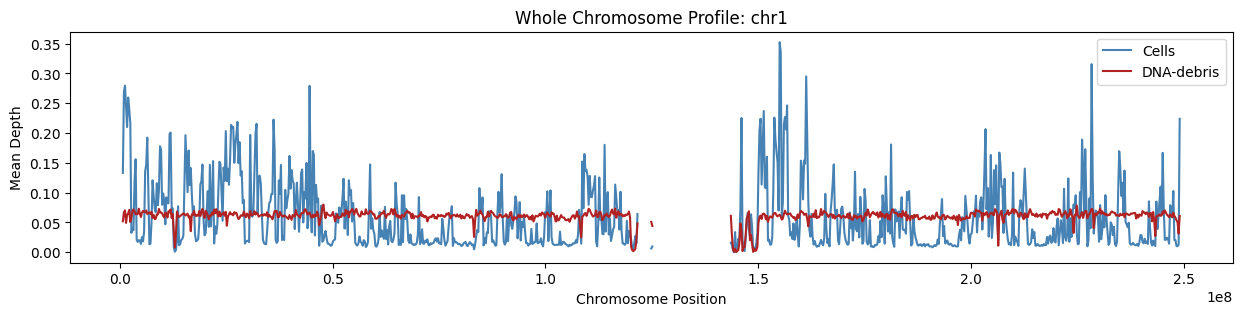

In [71]:
chrom = "chr1"

dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)

dna_debris_chrom_size = dna_debris_bw.chroms(chrom)
no_dna_debris_chrom_size = no_dna_debris_bw.chroms(chrom)



# Fetch the mean depth in 1000 equal-sized bins across the whole chromosome
bins = 1000
dna_debris_binned_stats = dna_debris_bw.stats(chrom, 0, dna_debris_chrom_size, nBins=bins, type="mean")
no_dna_debris_binned_stats = no_dna_debris_bw.stats(chrom, 0, no_dna_debris_chrom_size, nBins=bins, type="mean")

fig, ax = plt.subplots(figsize=(15, 3))

ax.plot(np.linspace(0, no_dna_debris_chrom_size, bins), no_dna_debris_binned_stats, color="steelblue", label="Cells")
ax.plot(np.linspace(0, dna_debris_chrom_size, bins), dna_debris_binned_stats, color="firebrick", label="DNA-debris")
ax.set_title(f"Whole Chromosome Profile: {chrom}")
ax.set_ylabel("Mean Depth")
ax.set_xlabel("Chromosome Position")
ax.legend()

no_dna_debris_bw.close()
dna_debris_bw.close()

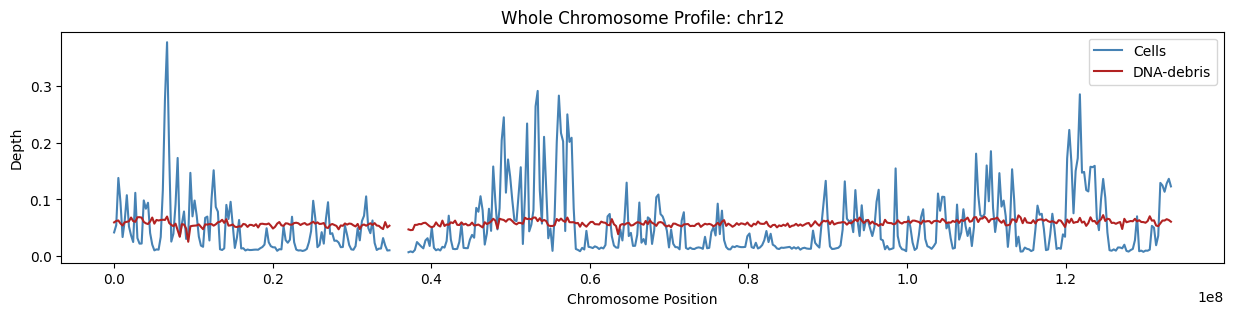

In [72]:
chrom = "chr12"

dna_debris_bw = pyBigWig.open(dna_debris_bw_file)
no_dna_debris_bw = pyBigWig.open(nodna_debris_bw_file)

dna_debris_chrom_size = dna_debris_bw.chroms(chrom)
no_dna_debris_chrom_size = no_dna_debris_bw.chroms(chrom)



# Fetch the mean depth in 1000 equal-sized bins across the whole chromosome
bins = 500
dna_debris_binned_stats = dna_debris_bw.stats(chrom, 0, dna_debris_chrom_size, nBins=bins, type="mean")
no_dna_debris_binned_stats = no_dna_debris_bw.stats(chrom, 0, no_dna_debris_chrom_size, nBins=bins, type="mean")

fig, ax = plt.subplots(figsize=(15, 3))

ax.plot(np.linspace(0, no_dna_debris_chrom_size, bins), no_dna_debris_binned_stats, color="steelblue", label="Cells")
ax.plot(np.linspace(0, dna_debris_chrom_size, bins), dna_debris_binned_stats, color="firebrick", label="DNA-debris")
ax.set_title(f"Whole Chromosome Profile: {chrom}")
ax.set_ylabel("Depth")
ax.set_xlabel("Chromosome Position")
ax.legend()

no_dna_debris_bw.close()
dna_debris_bw.close()

# Compare ST (SADE vs TSS)-cell-calling

In [28]:
tss_only_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_ST'] == 'tss_only', 'total_fragments'].sum()
entropy_only_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_ST'] == 'entropy_only', 'total_fragments'].sum()
common_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_ST'] == 'both', 'total_fragments'].sum()


## chromosome resolution

In [36]:
cmp_ST = os.path.join(Union_cells_subdir, 'cmp_ST')
mosdepth_res_subdir = os.path.join(cmp_ST, '_mosdepth_res')

chr_tss_only_file = os.path.join(mosdepth_res_subdir, 'tss_only.mosdepth.summary.txt')
chr_entropy_only_file = os.path.join(mosdepth_res_subdir, 'entropy_only.mosdepth.summary.txt')
chr_common_file = os.path.join(mosdepth_res_subdir, 'common.mosdepth.summary.txt')



chrCov_tss_only_file = os.path.join(mosdepth_res_subdir, 'tss_only.mosdepth.global.dist.txt')
chrCov_entropy_only_file = os.path.join(mosdepth_res_subdir, 'entropy_only.mosdepth.global.dist.txt')
chrCov_common_file = os.path.join(mosdepth_res_subdir, 'common.mosdepth.global.dist.txt')



chr_tss_only_df = pd.read_csv(chr_tss_only_file, sep='\t')
chr_entropy_only_df = pd.read_csv(chr_entropy_only_file, sep='\t')
chr_common_df = pd.read_csv(chr_common_file, sep='\t')

header = ['chrom', 'depth', 'baseCoverage_percent']
chrCov_tss_only_df = pd.read_csv(chrCov_tss_only_file, sep='\t', index_col=False, names=header)
chrCov_entropy_only_df = pd.read_csv(chrCov_entropy_only_file, sep='\t', index_col=False,names=header)
chrCov_common_df = pd.read_csv(chrCov_common_file, sep='\t', index_col=False,names=header)



for df, df_, pseudobulk_readdepth in zip([chr_tss_only_df, chr_entropy_only_df, chr_common_df], 
                   [chrCov_tss_only_df, chrCov_entropy_only_df, chrCov_common_df], 
                   [tss_only_pseudobulk_readdepth, entropy_only_pseudobulk_readdepth, common_pseudobulk_readdepth]):
    for chr in ['chr' + str(i) for i in range(1, 23)]:
        chrom_baseCov_Percentage = df_.loc[(df_['chrom'] == chr) & (df_['depth'] == 1), 'baseCoverage_percent'].values
        # Adjust the base coverage percentage by the pseudobulk read depth of each set, with reference to the common set
        df.loc[ df['chrom'] == chr , 'baseCoverage_percent'] = chrom_baseCov_Percentage #/ pseudobulk_readdepth * common_pseudobulk_readdepth
        
        


In [37]:
chrCov_tss_only_df.head(4)

,chrom,depth,baseCoverage_percent
0,chr1,3,0.00010
1,chr1,2,0.00072
2,chr1,1,0.01572
3,chr1,0,1.00000


In [38]:
chr_tss_only_df.head(2)

,chrom,length,bases,mean,min,max,baseCoverage_percent
0,chr1,248956422,4127501,0.01658,0,10,0.01572
1,chr10,133797422,2247657,0.01680,0,7,0.01604


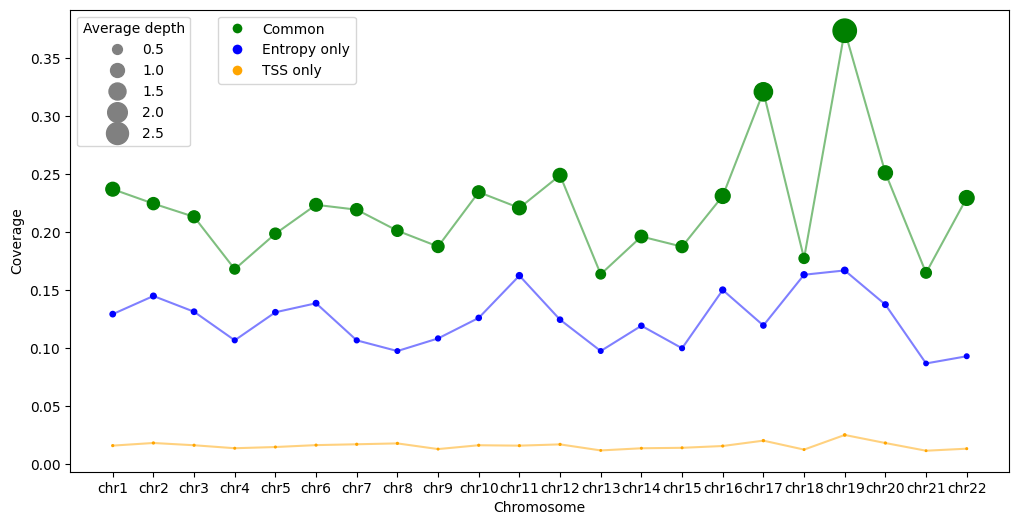

In [39]:

fig, (ax, legend_ax) = plt.subplots(figsize=(15, 6), ncols=2, gridspec_kw={'width_ratios': [8, 1]})
size_placeholder = []
for df, label, color in zip([chr_tss_only_df, chr_entropy_only_df, chr_common_df], 
                          ['tss_only', 'entropy_only', 'common'], 
                          ['orange', 'blue', 'green']):
    # only plot autosomes 
    df_ = df[df['chrom'].isin([f'chr{i}' for i in range(1, 23)])].copy()
    # reorder autosomes by chromosome number
    df_['_chrom'] = df_['chrom'].apply(lambda x: int(x.replace('chr', '')))
    df_ = df_.sort_values('_chrom')
    
    v1 = ax.scatter(df_['_chrom'], df_['baseCoverage_percent'] , label=label, color=color, s=df_['mean'] *100)
    _ = ax.plot(df_['_chrom'], df_['baseCoverage_percent'], color=color, alpha=0.5)

    size_placeholder = size_placeholder + df_['mean'].tolist()

_ = ax.set_xticks(df_['_chrom'])
_ = ax.set_xticklabels(df_['chrom'])
ax.set_xlabel('Chromosome')
ax.set_ylabel('Coverage')


scatter = legend_ax.scatter(np.arange(len(size_placeholder)), np.arange(len(size_placeholder)), color='blue', label='tss_only', s=[s *100 for s in size_placeholder])
legend_ax.set_visible(False)
# graft legend from legend_ax to ax
kw = dict(prop="sizes", num=6, color='grey', fmt="{x:.1f}",
          func=lambda s: s /100)
legend1 = ax.legend(*scatter.legend_elements(**kw),
                    loc="upper left", title="Average depth")
ax.add_artist(legend1)

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=8),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=8), 
                 Line2D([0], [0], marker='o', color='w', label='TSS only',
                           markerfacecolor='orange', markersize=8)],
             bbox_to_anchor=(0.15, 1), loc='upper left', ncol=1, fontsize=10)


plt.show()

## basepair resolution

In [ ]:


tss_only_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_tss_only.per-base.bed.gz')
entropy_only_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_entropy_only.per-base.bed.gz')
common_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_common.per-base.bed.gz')
# Columns: Chromosome, Start, End, Depth
df_tss_only= pd.read_csv(tss_only_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')
df_entropy_only= pd.read_csv(entropy_only_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')
df_common= pd.read_csv(common_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')

# Calculate the width of each interval (useful for finding outlier regions)
df_tss_only['width'] = df_tss_only['end'] - df_tss_only['start']
df_entropy_only['width'] = df_entropy_only['end'] - df_entropy_only['start']
df_common['width'] = df_common['end'] - df_common['start']

In [25]:
df_entropy_only.loc[df_entropy_only['depth'] / 191 > 2.0, ]


,chrom,start,end,depth,width
3389887,chr3,93470393,93470395,404,2
3389888,chr3,93470395,93470396,409,1
3389889,chr3,93470396,93470398,411,2
3389890,chr3,93470398,93470400,414,2
3389891,chr3,93470400,93470401,415,1
...,...,...,...,...,...
3390156,chr3,93470760,93470761,417,1
3390157,chr3,93470761,93470762,414,1
3390158,chr3,93470762,93470763,410,1
3390159,chr3,93470763,93470764,407,1


In [18]:
# calculate depth ratio 
_df =pd.DataFrame(columns=['type', 'depth', 'bp_coverage'],)

for df, type in zip([df_tss_only, df_entropy_only, df_common], ['tss_only', 'entropy_only', 'common']):
    for depth in df['depth'].unique():
        total_bp = df[df['depth'] == depth]['width'].sum()
        # add row to dataframe
        _df.loc[len(_df)] = [type, depth, total_bp]


In [ ]:
_df.loc[_df['type'] == 'tss_only', 'depth_norm_by_droplets'] = _df[_df['type'] == 'tss_only']['depth'] / 222 
_df.loc[_df['type'] == 'entropy_only', 'depth_norm_by_droplets'] = _df[_df['type'] == 'entropy_only']['depth'] / 191
_df.loc[_df['type'] == 'common', 'depth_norm_by_droplets'] = _df[_df['type'] == 'common']['depth'] / 1910



_df.loc[_df['type'] == 'cr_only', 'bp_perc'] = _df[_df['type'] == 'cr_only']['bp_coverage'] /  _df[_df['type'] == 'cr_only']['bp_coverage'].sum()
_df.loc[_df['type'] == 'entropy_only', 'bp_perc'] = _df[_df['type'] == 'entropy_only']['bp_coverage'] /  _df[_df['type'] == 'entropy_only']['bp_coverage'].sum()
_df.loc[_df['type'] == 'common', 'bp_perc'] = _df[_df['type'] == 'common']['bp_coverage'] /  _df[_df['type'] == 'common']['bp_coverage'].sum()

Text(0, 0.5, 'Depth normalized by number of droplets')

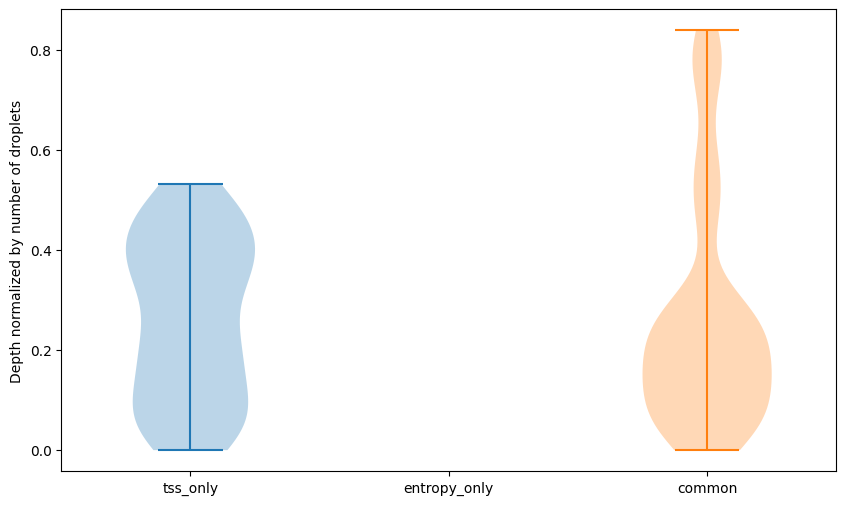

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.violinplot(_df[_df['type'] == 'tss_only']['depth_norm_by_droplets'], positions=[0])
# ax.violinplot(_df[_df['type'] == 'entropy_only']['depth_norm_by_droplets'], positions=[1])
ax.violinplot(_df[_df['type'] == 'common']['depth_norm_by_droplets'], positions=[2])
ax.set_xlim(-0.5, 2.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['tss_only', 'entropy_only', 'common'])
ax.set_ylabel('Depth normalized by number of droplets')

Coverage at chr6:32352749-32552077


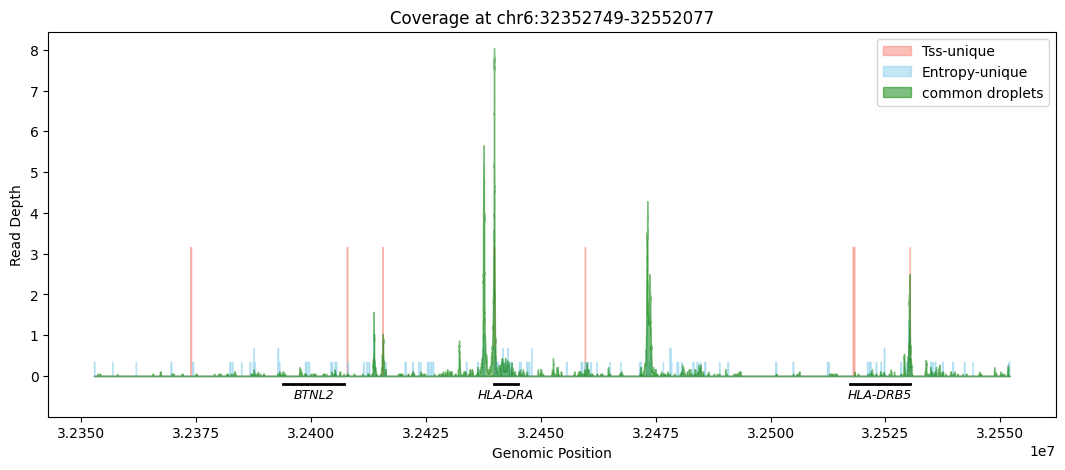

In [ ]:

chrom = "chr6"
start = 32352749
end = 32552077

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]


cmp_ST_subdir = os.path.join(Union_cells_subdir, 'cmp_ST')
Tss_unique_bw_file = os.path.join(cmp_ST_subdir, 'tss_only_bc_fragments.CPM.bw')
entropy_unique_bw_file = os.path.join(cmp_ST_subdir, 'entropy_only_bc_fragments.CPM.bw')
common_bw_file = os.path.join(cmp_ST_subdir, 'common_bc_fragments.CPM.bw')

# Open the BigWig file
Tss_unique_bw = pyBigWig.open(Tss_unique_bw_file)
entropy_unique_bw = pyBigWig.open(entropy_unique_bw_file)
common_bw = pyBigWig.open(common_bw_file)


# Extract values (returns a list offloats, one per base) & replace NaNs with 0
Tss_unique_values = Tss_unique_bw.values(chrom, start, end)
Tss_unique_values = np.nan_to_num(Tss_unique_values, nan=0.0)
entropy_unique_values = entropy_unique_bw.values(chrom, start, end)
entropy_unique_values = np.nan_to_num(entropy_unique_values, nan=0.0)
common_bc_values = common_bw.values(chrom, start, end)
common_bc_values = np.nan_to_num(common_bc_values, nan=0.0)


fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)


ax_cov.fill_between(range(start, end), Tss_unique_values, color="salmon", alpha=0.5, label='Tss-unique')
ax_cov.fill_between(range(start, end), entropy_unique_values, color="skyblue", alpha=0.5, label='Entropy-unique')
ax_cov.fill_between(range(start, end), common_bc_values, color='green', alpha=0.5, label='common droplets' )
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05, step=1))




print(f"Coverage at {chrom}:{start}-{end}")

Tss_unique_bw.close()
entropy_unique_bw.close()

Coverage at chr19:51500861-51593411


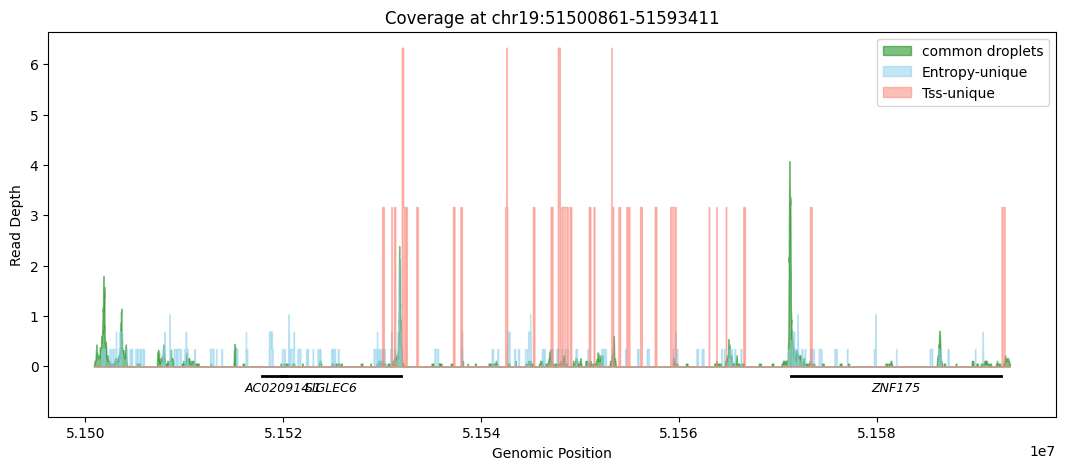

In [12]:
# region of interest
chrom = "chr19"
start = 51500861
end = 51593411

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]


# Open the BigWig file
Tss_unique_bw = pyBigWig.open(Tss_unique_bw_file)
entropy_unique_bw = pyBigWig.open(entropy_unique_bw_file)
common_bw = pyBigWig.open(common_bw_file)


# Extract values (returns a list of floats, one per base) & replace NaNs with 0
Tss_unique_values = Tss_unique_bw.values(chrom, start, end)
Tss_unique_values = np.nan_to_num(Tss_unique_values, nan=0.0)
entropy_unique_values = entropy_unique_bw.values(chrom, start, end)
entropy_unique_values = np.nan_to_num(entropy_unique_values, nan=0.0)
common_bc_values = common_bw.values(chrom, start, end)
common_bc_values = np.nan_to_num(common_bc_values, nan=0.0)


fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)

ax_cov.fill_between(range(start, end), common_bc_values, color='green', alpha=0.5, label='common droplets' )
ax_cov.fill_between(range(start, end), entropy_unique_values, color="skyblue", alpha=0.5, label='Entropy-unique')
ax_cov.fill_between(range(start, end), Tss_unique_values, color="salmon", alpha=0.5, label='Tss-unique')
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05, step=1))




print(f"Coverage at {chrom}:{start}-{end}")

Tss_unique_bw.close()
entropy_unique_bw.close()

Coverage at chr1:51600861-51643411


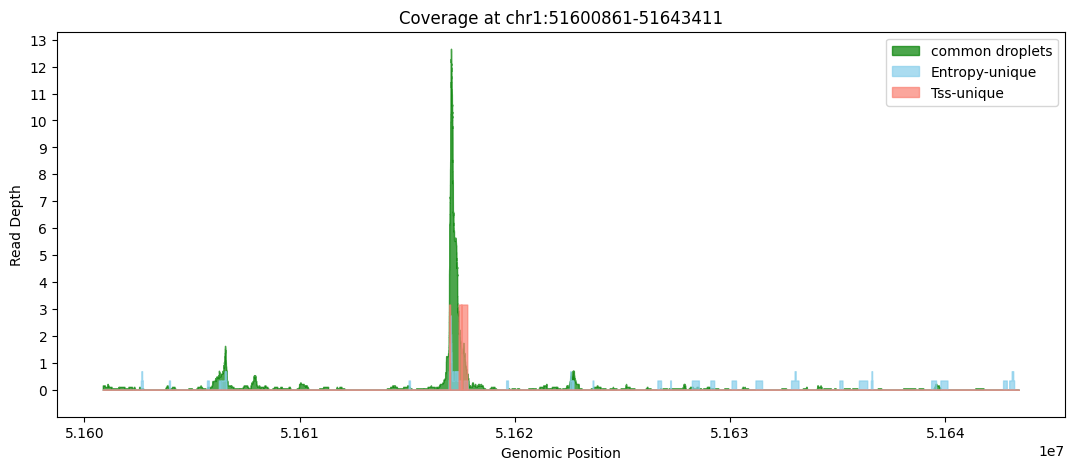

In [24]:
# region of interest
chrom = "chr1"
start = 51600861
end = 51643411

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]


# Open the BigWig file
Tss_unique_bw = pyBigWig.open(Tss_unique_bw_file)
entropy_unique_bw = pyBigWig.open(entropy_unique_bw_file)
common_bw = pyBigWig.open(common_bw_file)


# Extract values (returns a list of floats, one per base) & replace NaNs with 0
Tss_unique_values = Tss_unique_bw.values(chrom, start, end)
Tss_unique_values = np.nan_to_num(Tss_unique_values, nan=0.0)
entropy_unique_values = entropy_unique_bw.values(chrom, start, end)
entropy_unique_values = np.nan_to_num(entropy_unique_values, nan=0.0)
common_bc_values = common_bw.values(chrom, start, end)
common_bc_values = np.nan_to_num(common_bc_values, nan=0.0)


fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)

ax_cov.fill_between(range(start, end), common_bc_values, color='green', alpha=0.7, label='common droplets' )
ax_cov.fill_between(range(start, end), entropy_unique_values, color="skyblue", alpha=0.7, label='Entropy-unique')
ax_cov.fill_between(range(start, end), Tss_unique_values, color="salmon", alpha=0.7, label='Tss-unique')
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05, step=1))




print(f"Coverage at {chrom}:{start}-{end}")

Tss_unique_bw.close()
entropy_unique_bw.close()

Coverage at chr19:51500861-51593411


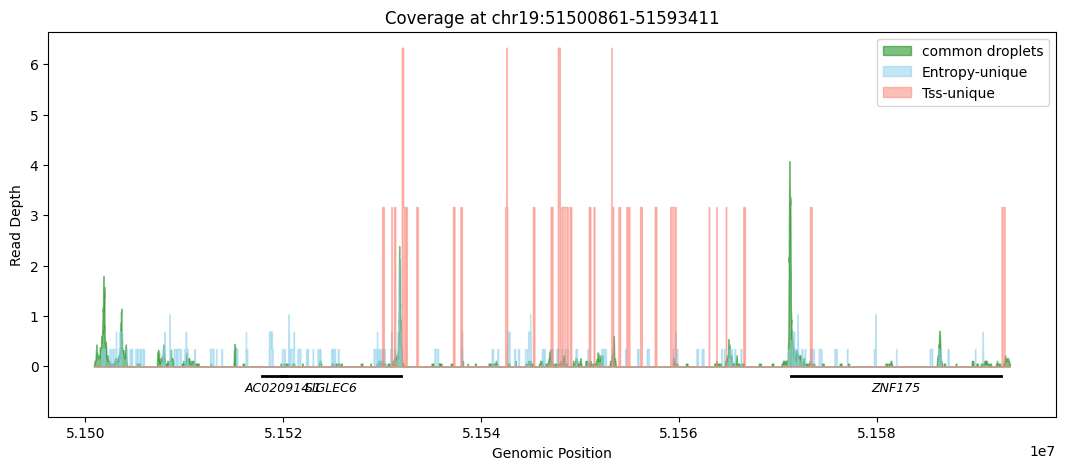

In [ ]:
# region of interest
chrom = "chr19"
start = 51500861
end = 51593411

genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]


# Open the BigWig file
Tss_unique_bw = pyBigWig.open(Tss_unique_bw_file)
entropy_unique_bw = pyBigWig.open(entropy_unique_bw_file)
common_bw = pyBigWig.open(common_bw_file)


# Extract values (returns a list of floats, one per base) & replace NaNs with 0
Tss_unique_values = Tss_unique_bw.values(chrom, start, end)
Tss_unique_values = np.nan_to_num(Tss_unique_values, nan=0.0)
entropy_unique_values = entropy_unique_bw.values(chrom, start, end)
entropy_unique_values = np.nan_to_num(entropy_unique_values, nan=0.0)
common_bc_values = common_bw.values(chrom, start, end)
common_bc_values = np.nan_to_num(common_bc_values, nan=0.0)


fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)

ax_cov.fill_between(range(start, end), common_bc_values, color='green', alpha=0.5, label='common droplets' )
ax_cov.fill_between(range(start, end), entropy_unique_values, color="skyblue", alpha=0.5, label='Entropy-unique')
ax_cov.fill_between(range(start, end), Tss_unique_values, color="salmon", alpha=0.5, label='Tss-unique')
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(Tss_unique_values), max(entropy_unique_values), max(common_bc_values)) * 1.05, step=1))




print(f"Coverage at {chrom}:{start}-{end}")

Tss_unique_bw.close()
entropy_unique_bw.close()

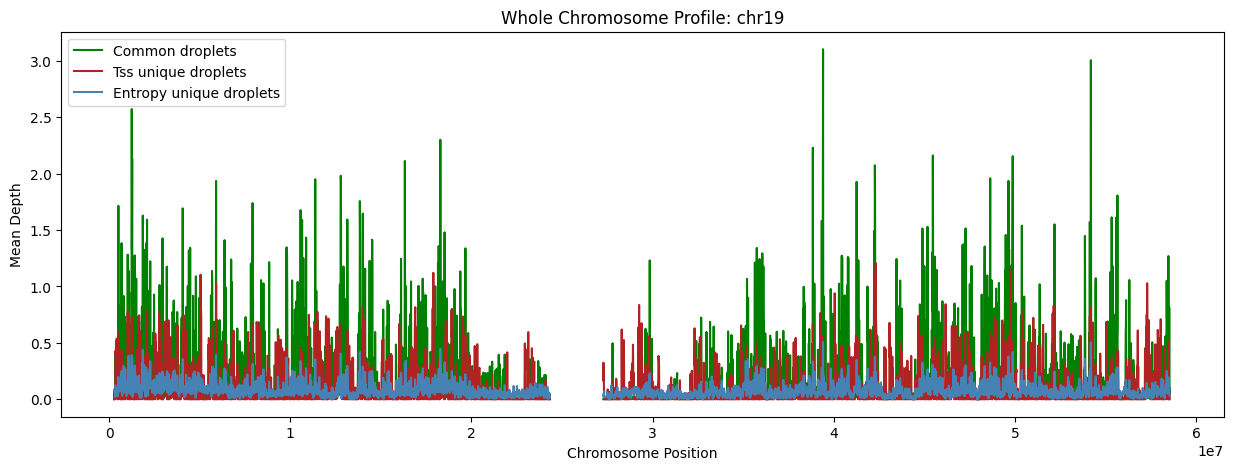

In [8]:
chrom = "chr19"

Tss_unique_bw = pyBigWig.open(Tss_unique_bw_file)
entropy_unique_bw = pyBigWig.open(entropy_unique_bw_file)
common_bc_bw = pyBigWig.open(common_bw_file)

Tss_unique_chrom_size = Tss_unique_bw.chroms(chrom)
entropy_unique_chrom_size = entropy_unique_bw.chroms(chrom)
common_chrom_size = common_bw.chroms(chrom)

# Fetch the mean depth in 1000 equal-sized bins across the whole chromosome
bins = 5000
Tss_unique_binned_stats = Tss_unique_bw.stats(chrom, 0, Tss_unique_chrom_size, nBins=bins, type="mean")
entropy_unique_binned_stats = entropy_unique_bw.stats(chrom, 0, entropy_unique_chrom_size, nBins=bins, type="mean")
common_bc_binned_stats = common_bc_bw.stats(chrom, 0, common_chrom_size, nBins=bins, type="mean")

plt.figure(figsize=(15, 5))
plt.plot(np.linspace(0, common_chrom_size, bins), common_bc_binned_stats, color="green", label="Common droplets")
plt.plot(np.linspace(0, Tss_unique_chrom_size, bins), Tss_unique_binned_stats, color="firebrick", label="Tss unique droplets")
plt.plot(np.linspace(0, entropy_unique_chrom_size, bins), entropy_unique_binned_stats, color="steelblue", label="Entropy unique droplets")
plt.title(f"Whole Chromosome Profile: {chrom}")
plt.ylabel("Mean Depth")
plt.xlabel("Chromosome Position")
plt.legend()
plt.show()

In [4]:
one_bc_bw_file = os.path.join(Union_cells_subdir, 'TSS_bc_lowFRIP_bc/individual_bc_frag', 'sorted_farg_bc_1.bw')


Coverage at chr1:33277276-33858073


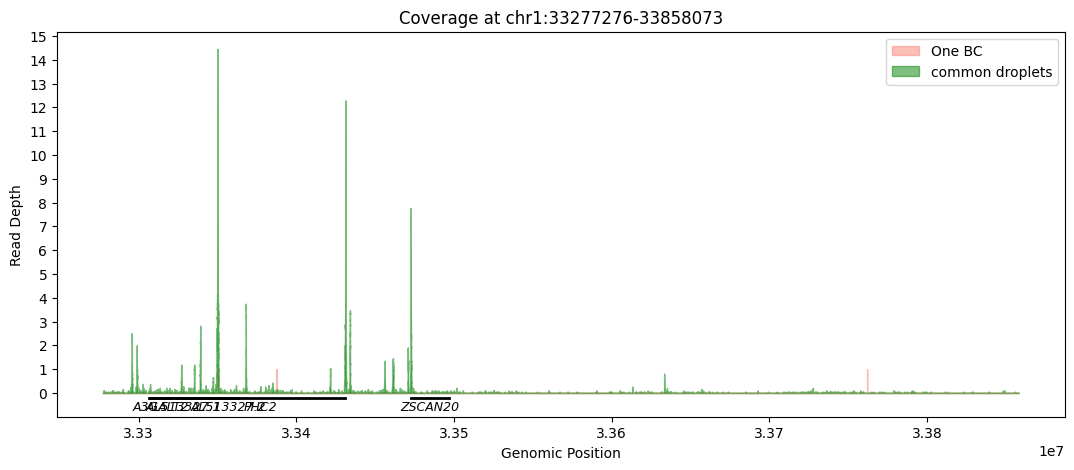

In [9]:
chrom = "chr1"
start = 33277276
end = 33858073


genes_in_region = (hg38_genes_genes_df['chrom'] == chrom) & (hg38_genes_genes_df['start'] >= start) & (hg38_genes_genes_df['end'] <= end)
genes = hg38_genes_genes_df[genes_in_region][['gene_name', 'start', 'end']]



# Open the BigWig file
one_bc_bw = pyBigWig.open(one_bc_bw_file)
common_bc_bw = pyBigWig.open(common_bw_file)
# Define your region of interest


# Extract values (returns a list of floats, one per base) & replace NaNs with 0
one_bc_values = one_bc_bw.values(chrom, start, end)
one_bc_values = np.nan_to_num(one_bc_values, nan=0.0)
common_bc_values = common_bc_bw.values(chrom, start, end)
common_bc_values = np.nan_to_num(common_bc_values, nan=0.0)


fig, (ax_cov)= plt.subplots(1, 1, figsize=(13, 5), 
)


ax_cov.fill_between(range(start, end), one_bc_values, color="salmon", alpha=0.5, label='One BC')
ax_cov.fill_between(range(start, end), common_bc_values, color='green', alpha=0.5, label='common droplets' )
ax_cov.set_title(f"Coverage at {chrom}:{start}-{end}")
ax_cov.set_xlabel("Genomic Position")
ax_cov.set_ylabel("Read Depth")
ax_cov.legend()



# Bottom Panel: Gene Annotations
for gene in genes.itertuples():
    # Draw the main gene line (Intron)
    ax_cov.plot([gene.start, gene.end], [-0.2, -0.2], color='black', lw=2)
    
    # Add Gene Name
    ax_cov.text((gene.start + gene.end)/2, -0.3, gene.gene_name, 
                ha='center', va='top', fontsize=9, fontstyle='italic')

ax_cov.tick_params(labelbottom=True, which='both')
ax_cov.set_ylim(-1, max(max(one_bc_values), max(common_bc_values)) * 1.05)
ax_cov.set_yticks(np.arange(0, max(max(one_bc_values), max(common_bc_values)) * 1.05, step=1))




print(f"Coverage at {chrom}:{start}-{end}")

one_bc_bw.close()
common_bw.close()

# Comparison of SC (SADE v.s. CR-frip)

In [23]:
cr_only_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_SC'] == 'cr_only', 'total_fragments'].sum()
entropy_only_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_SC'] == 'entropy_only', 'total_fragments'].sum()
common_pseudobulk_readdepth = Union_3set_atac_BCs_df.loc[Union_3set_atac_BCs_df['_2set_identified_by_atac_SC'] == 'both', 'total_fragments'].sum()


## Chromosome resolution

In [34]:
mosdepth_res_subdir = os.path.join(Union_cells_subdir, 'cmp_SC', '_mosdepth_res')

chr_cr_only_file = os.path.join(mosdepth_res_subdir, 'cr_only.mosdepth.summary.txt')
chr_entropy_only_file = os.path.join(mosdepth_res_subdir, 'entropy_only.mosdepth.summary.txt')
chr_common_file = os.path.join(mosdepth_res_subdir, 'common.mosdepth.summary.txt')



chrCov_cr_only_file = os.path.join(mosdepth_res_subdir, 'cr_only.mosdepth.global.dist.txt')
chrCov_entropy_only_file = os.path.join(mosdepth_res_subdir, 'entropy_only.mosdepth.global.dist.txt')
chrCov_common_file = os.path.join(mosdepth_res_subdir, 'common.mosdepth.global.dist.txt')



chr_cr_only_df = pd.read_csv(chr_cr_only_file, sep='\t')
chr_entropy_only_df = pd.read_csv(chr_entropy_only_file, sep='\t')
chr_common_df = pd.read_csv(chr_common_file, sep='\t')

header = ['chrom', 'depth', 'baseCoverage_percent']
chrCov_cr_only_df = pd.read_csv(chrCov_cr_only_file, sep='\t', index_col=False, names=header)
chrCov_entropy_only_df = pd.read_csv(chrCov_entropy_only_file, sep='\t', index_col=False,names=header)
chrCov_common_df = pd.read_csv(chrCov_common_file, sep='\t', index_col=False,names=header)



for df, df_, pseudobulk_readdepth in zip([chr_cr_only_df, chr_entropy_only_df, chr_common_df], 
                   [chrCov_cr_only_df, chrCov_entropy_only_df, chrCov_common_df], 
                   [cr_only_pseudobulk_readdepth, entropy_only_pseudobulk_readdepth, common_pseudobulk_readdepth]):
    for chr in ['chr' + str(i) for i in range(1, 23)]:
        chrom_baseCov_Percentage = df_.loc[(df_['chrom'] == chr) & (df_['depth'] == 1), 'baseCoverage_percent'].values
        df.loc[ df['chrom'] == chr , 'baseCoverage_percent'] = chrom_baseCov_Percentage #/ pseudobulk_readdepth * common_pseudobulk_readdepth
        

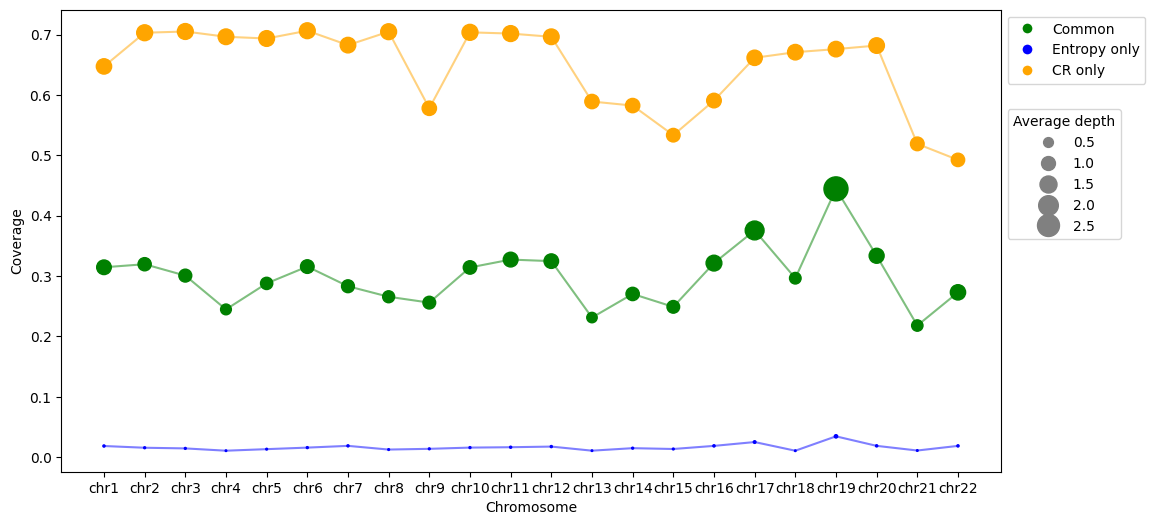

In [35]:

fig, (ax, legend_ax) = plt.subplots(figsize=(15, 6), ncols=2, gridspec_kw={'width_ratios': [8, 1]})
size_placeholder = []
for df, label, color in zip([chr_cr_only_df, chr_entropy_only_df, chr_common_df], 
                          ['cr_only', 'entropy_only', 'common'], 
                          ['orange', 'blue', 'green']):
    # only plot autosomes 
    df_ = df[df['chrom'].isin([f'chr{i}' for i in range(1, 23)])].copy()
    # reorder autosomes by chromosome number
    df_['_chrom'] = df_['chrom'].apply(lambda x: int(x.replace('chr', '')))
    df_ = df_.sort_values('_chrom')
    
    v1 = ax.scatter(df_['_chrom'], df_['baseCoverage_percent'] , label=label, color=color, s=df_['mean'] *100)
    _ = ax.plot(df_['_chrom'], df_['baseCoverage_percent'], color=color, alpha=0.5)
    size_placeholder = size_placeholder + df_['mean'].tolist()

_ = ax.set_xticks(df_['_chrom'])
_ = ax.set_xticklabels(df_['chrom'])
ax.set_xlabel('Chromosome')
ax.set_ylabel('Coverage')


scatter = legend_ax.scatter(np.arange(len(size_placeholder)), np.arange(len(size_placeholder)), s=[s *100 for s in size_placeholder])

legend_ax.set_visible(False)
# graft legend from legend_ax to ax
kw = dict(prop="sizes", num=6, color='grey', fmt="{x:.1f}",
          func=lambda s: s /100)
legend1 = ax.legend(*scatter.legend_elements(**kw),
                    loc="upper left", title="Average depth", 
                    bbox_to_anchor=(1, 0.8))
ax.add_artist(legend1)

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=8),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=8), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=8)],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=10)


plt.show()

## Basepair resolution

In [ ]:
cmp_SC = os.path.join(Union_cells_subdir, 'cmp_SC')
mosdepth_res_subdir = os.path.join(cmp_SC, '_mosdepth_res')


cr_only_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_cr_only.per-base.bed.gz')
entropy_only_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_entropy_only.per-base.bed.gz')
common_per_base_file = os.path.join(mosdepth_res_subdir, 'RmBlacklist_common.per-base.bed.gz')
# Columns: Chromosome, Start, End, Depth
df2_cr_only= pd.read_csv(cr_only_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')
df2_entropy_only= pd.read_csv(entropy_only_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')
df2_common= pd.read_csv(common_per_base_file, sep='\t', 
                 names=['chrom', 'start', 'end', 'depth'], 
                 compression='gzip')

# Calculate the width of each interval (useful for finding outlier regions)
df2_cr_only['width'] = df2_cr_only['end'] - df2_cr_only['start']
df2_entropy_only['width'] = df2_entropy_only['end'] - df2_entropy_only['start']
df2_common['width'] = df2_common['end'] - df2_common['start']

In [ ]:
_df2 =pd.DataFrame(columns=['type', 'depth', 'bp_coverage'],)

for df, type in zip([df2_cr_only, df2_entropy_only, df2_common], ['cr_only', 'entropy_only', 'common']):
    for depth in df['depth'].unique():
        total_bp = df[df['depth'] == depth]['width'].sum()
        _df2.loc[len(_df2)] = [type, depth, total_bp]

In [ ]:
_df2.loc[_df2['type'] == 'cr_only', 'depth_norm_by_droplets'] = _df2[_df2['type'] == 'cr_only']['depth'] / 94 
_df2.loc[_df2['type'] == 'entropy_only', 'depth_norm_by_droplets'] = _df2[_df2['type'] == 'entropy_only']['depth'] / 236
_df2.loc[_df2['type'] == 'common', 'depth_norm_by_droplets'] = _df2[_df2['type'] == 'common']['depth'] / 1865


_df2.loc[_df2['type'] == 'cr_only', 'bp_perc'] = _df2[_df2['type'] == 'cr_only']['bp_coverage'] /  _df2[_df2['type'] == 'cr_only']['bp_coverage'].sum()
_df2.loc[_df2['type'] == 'entropy_only', 'bp_perc'] = _df2[_df2['type'] == 'entropy_only']['bp_coverage'] /  _df2[_df2['type'] == 'entropy_only']['bp_coverage'].sum()
_df2.loc[_df2['type'] == 'common', 'bp_perc'] = _df2[_df2['type'] == 'common']['bp_coverage'] /  _df2[_df2['type'] == 'common']['bp_coverage'].sum()